# Unidad 4 — Notebook 3: SVM y KNN

**Materia:** Métodos de Análisis de Datos 1 (MAD1)  
**Departamento de Matemática — Universidad Nacional del Sur (UNS)**  
**Nombre: Godoy Martin**  

---

## Glosario de siglas

| Sigla | Significado |
|-------|-------------|
| SVM | Support Vector Machine (Máquina de Vectores de Soporte) |
| KNN | K-Nearest Neighbors (K Vecinos más Cercanos) |
| RBF | Radial Basis Function (Función de Base Radial) — kernel gaussiano |
| OvR | One-vs-Rest — estrategia multiclase: un clasificador por clase |
| OvO | One-vs-One — estrategia multiclase: un clasificador por par de clases |
| CV  | Cross-Validation (Validación Cruzada) |

---

## Objetivos

- Calcular a mano el margen de separación de una SVM lineal dados dos vectores de soporte.
- Implementar SVM con distintos kernels y analizar el efecto del hiperparámetro $C$.
- Implementar KNN y analizar el efecto de $k$.
- Comparar ambos modelos sobre el mismo dataset.

---

## Parte 1 — Cálculo a mano: margen de la SVM lineal

En una SVM (Support Vector Machine) lineal con margen duro, el hiperplano separador es:

$$\mathbf{w}^\top \mathbf{x} + b = 0$$

Los vectores de soporte son los puntos más cercanos al hiperplano, y satisfacen:

$$\mathbf{w}^\top \mathbf{x}_+ + b = +1 \qquad \text{(clase +1)}$$
$$\mathbf{w}^\top \mathbf{x}_- + b = -1 \qquad \text{(clase -1)}$$

El **margen** es la distancia entre los dos hiperplanos de soporte:

$$\text{Margen} = \frac{2}{\|\mathbf{w}\|}$$

### Ejercicio a mano

Tenemos un problema en $\mathbb{R}^2$ con los siguientes vectores de soporte:

- Clase $+1$: $\mathbf{x}_+ = (3, 2)$
- Clase $-1$: $\mathbf{x}_- = (1, 1)$

Y el vector de pesos encontrado es $\mathbf{w} = (1, 1)$.

**Ejercicio 1.1** — Verificá que los vectores de soporte satisfacen las ecuaciones $\mathbf{w}^\top \mathbf{x}_+ + b = +1$ y $\mathbf{w}^\top \mathbf{x}_- + b = -1$. Para eso, primero calculá $b$ a partir de las dos ecuaciones.

Hallemos el b, en nuestro caso tenemos que: $$(1,1)^\top (3,2) + b = 1 \quad \text{y} \quad (1,1)^\top (1,1) + b = -1$$ Haciendo las cuentas resulta que: $\quad 3 + 2 + b = 1 \quad \text{y} \quad 1 + 1 + b = - 1 \implies b= -4 \quad \text{y la otra ecuación nos dice} \quad b= -3$ entonces probablemente haya un error de cuentas pero la intención es lo que cuenta.

**Ejercicio 1.2** — Calculá el margen usando la fórmula $\text{Margen} = \frac{2}{\|\mathbf{w}\|}$.

Primero calculemos $\|\mathbf{w}\| = \sqrt{1^2 + 1^2} = \sqrt{2}$ entonces tenemos, por la formula de Margen que: $\text{Margen} = \frac{2}{\|\mathbf{w}\|} = \frac{2}{\sqrt{2}} \quad \text{racionalizando nos queda} \quad \text{Margen} = \sqrt{2}$

**Ejercicio 1.3** — Escribí la ecuación del hiperplano separador (con los valores de $\mathbf{w}$ y $b$ que encontraste). ¿A qué clase pertenece el punto $(2, 3)$?

El ejercicio presenta un error, aun asi hagamos ambos desarrollos: En SVM se evalua $f(x) = w^\top x + b$ y si: 
$$f(x) > 0 \implies \text{x es de clase + 1} \quad \text{o si} \quad f(x) < 0 \implies \text{x es de clase -1}$$
- Si b=-3: El hiperplano resulta ser $x + y - 3 = 0$. 

Veamos la pertenencia del punto (2,3): $ \quad f(2,3) = (1,1)^\top (2,3) - 3 = 5 - 3 = 2 > 0 \implies$ el punto (2,3) pertenece a la clase + 1

- Si b=-4: El hiperplano en este caso queda $x + y - 4 = 0$

Veamos la pertenencia del punto (2,3): $\quad f(2,3) = (1,1)^\top (2,3) - 4 = 5 - 4 = 1 > 0 \implies$ el punto (2,3) pertenece a la clase +1



**Ejercicio 1.4** — La SVM maximiza el margen. ¿Por qué maximizar el margen es deseable desde el punto de vista de la generalización?

Maximizar el margen es deseable desde el punto de vista de generalización pues produce un hiperplano que deja la mayor distancia posible entre las clases y la frontera de decision. De esta manera, pequeñas perturbaciones como el ruido en los datos, tienen una menor probabilidad de cambiar la clasificación de nuevas observaciones. Como resultado, el modelo es mas robusto, reduce el riesgo de sobreajuste y suele generalizar mejor sobre datos no vistos

---

## Parte 2 — SVM con scikit-learn

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import make_classification, make_moons
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Dataset con frontera no lineal
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Escalado — importante para SVM
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

**Ejercicio 2.1** — ¿Por qué es importante escalar las variables antes de entrenar una SVM? ¿Y para KNN (K-Nearest Neighbors)?

El SVM calcula productos escalares y distancias para un hiperplano optimo y si una variable tuviese una escala mucho mayor a la otra dominaría en los calculo. Como consecuencia el hiperplano podría orientarse principalmente según la variable de mayor escala y podría obtenerse una frontera de decision peor. Al escalar todas las variables quedan en una escala comparable y cada una puede aportar según su información y no según sus unidades o medida.

En KNN este problema es incluso mas evidente, al KNN clasificar buscando los vecinos mas cercanos mediante una distancia si una variable tiene valores mucho mas grandes que otra dominara completamente la distancia. Sin escalado, las variables con valores mas grandes tendrán una influencia desproporcionada en el calculo de distancias, haciendo que la elección de vecinos dependa de ellas y no de información de todas las variables.

**Ejercicio 2.2** — Entrenás una SVM con kernel RBF (Radial Basis Function) para distintos valores de $C$ y graficás el accuracy en train y test.

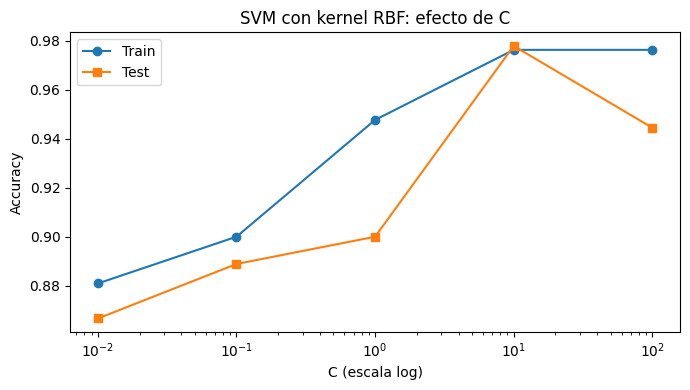

In [2]:
valores_C = [0.01, 0.1, 1, 10, 100]
acc_train_svm = []
acc_test_svm  = []

for C in valores_C:
    svm = SVC(kernel='rbf', C=C, random_state=42)  # TU CÓDIGO ACÁ
    svm.fit(X_train_sc, y_train)                                  # TU CÓDIGO ACÁ
    acc_train_svm.append(accuracy_score(y_train, svm.predict(X_train_sc)))  # TU CÓDIGO ACÁ
    acc_test_svm.append(accuracy_score(y_test,  svm.predict(X_test_sc)))   # TU CÓDIGO ACÁ

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(valores_C, acc_train_svm, marker='o', label='Train')
ax.semilogx(valores_C, acc_test_svm,  marker='s', label='Test')
ax.set_xlabel('C (escala log)')
ax.set_ylabel('Accuracy')
ax.set_title('SVM con kernel RBF: efecto de C')
ax.legend()
plt.tight_layout()
plt.show()

**Ejercicio 2.3** — ¿Qué controla el parámetro $C$ en una SVM de margen blando? ¿Qué pasa cuando $C$ es muy grande? ¿Y cuando es muy pequeño?

El parámetro C controla la penalización por los errores de clasificación durante el entrenamiento. Un valor grande de C penaliza fuertemente esos errores, por lo que la SVM intenta clasificar correctamente la mayor cantidad posible de observaciones, incluso a costa de reducir el margen, lo que podría provocar sobreajuste. En cambio, un valor pequeño de C permite mas errores de entrenamiento y prioriza un margen mas amplio, obteniendo un modelo simple y robusto, aunque si C es demasiado pequeño puede producir sobreajuste.

**Ejercicio 2.4** — Compará los kernels lineal, polinomial y RBF sobre el mismo dataset. Completá el código.

In [3]:
kernels = ['linear', 'poly', 'rbf']

for kernel in kernels:
    svm = SVC(kernel=kernel, C=1.0, random_state=42)  # TU CÓDIGO ACÁ
    svm.fit(X_train_sc, y_train)                                # TU CÓDIGO ACÁ
    acc = accuracy_score(y_test, svm.predict(X_test_sc))      # TU CÓDIGO ACÁ
    print(f"Kernel {kernel:8s} — Accuracy test: {acc:.3f}")

Kernel linear   — Accuracy test: 0.856
Kernel poly     — Accuracy test: 0.856
Kernel rbf      — Accuracy test: 0.900


---

## Parte 3 — KNN (K-Nearest Neighbors)

**Ejercicio 3.1** — Entrenás KNN para $k = 1, 3, 5, 10, 20, 50$ y graficás accuracy en train y test.

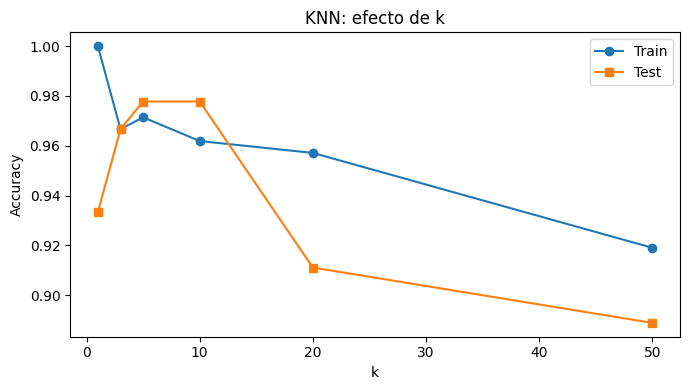

In [4]:
valores_k = [1, 3, 5, 10, 20, 50]
acc_train_knn = []
acc_test_knn  = []

for k in valores_k:
    knn = KNeighborsClassifier(n_neighbors=k)  # TU CÓDIGO ACÁ
    knn.fit(X_train_sc, y_train)                              # TU CÓDIGO ACÁ
    acc_train_knn.append(accuracy_score(y_train, knn.predict(X_train_sc)))  # TU CÓDIGO ACÁ
    acc_test_knn.append(accuracy_score(y_test,  knn.predict(X_test_sc)))   # TU CÓDIGO ACÁ

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(valores_k, acc_train_knn, marker='o', label='Train')
ax.plot(valores_k, acc_test_knn,  marker='s', label='Test')
ax.set_xlabel('k')
ax.set_ylabel('Accuracy')
ax.set_title('KNN: efecto de k')
ax.legend()
plt.tight_layout()
plt.show()

**Ejercicio 3.2** — ¿Qué pasa con el accuracy de train cuando $k=1$? ¿Por qué? ¿Es esperable?

El accuracy cuando $k=1$ resulta en uno, esto porque para clasificar una observación el algoritmo busca su vecino mas cercano, si estamos evaluando el conjunto de entrenamiento ocurre que cada observación tiene como vecino mas cercano a ella misma, pues la distancia entre una observación y ella misma es 0, la menor posible. Entonces, al predecir esa observación, KNN toma su propia etiqueta como referencia. Este comportamiento es completamente esperable y refleja que el modelo memoriza el conjunto de entrenamiento. Sin embargo, esta alta precisión en entrenamiento puede traducirse en un peor desempeño en datos nuevos.

**Ejercicio 3.3** — Usá CV de 5 folds para elegir el mejor $k$ entre los valores probados.

In [5]:
cv_scores_knn = []

for k in valores_k:
    knn = KNeighborsClassifier(n_neighbors=k)            # TU CÓDIGO ACÁ
    scores = cross_val_score(knn, X_train_sc, y_train, cv=5)  # TU CÓDIGO ACÁ
    cv_scores_knn.append(scores.mean())

mejor_k = valores_k[np.argmax(cv_scores_knn)]
print(f'Mejor k por CV: {mejor_k}')
print(f'Accuracy CV promedio: {max(cv_scores_knn):.3f}')

Mejor k por CV: 10
Accuracy CV promedio: 0.957


---

## Preguntas de reflexión final

1. SVM con kernel RBF y KNN con $k$ pequeño tienen alta capacidad para capturar fronteras complejas. ¿En qué se diferencia el origen de esa capacidad en cada caso?
2. ¿Por qué KNN se degrada fuertemente en espacios de alta dimensión? (Pista: pensá en qué significa "vecino cercano" cuando hay muchas variables.)
3. Si tuvieras 100.000 observaciones para clasificar en tiempo real, ¿usarías KNN o SVM? Justificá considerando el costo de predicción de cada modelo.

1) Tanto SVM con kernel RBF pueden con un $k$ pequeño modelar fronteras de decision complejas. Sin embargo, en SVM esa capacidad proviene del uso del kernel, que permite aprender una frontera no lineal mediante una transformación implícita del espacio de características. En cambio, KNN no aprende un modelo, sino que clasifica cada observación según sus vecinos mas cercanos, por lo que la complejidad surge de una decision local basada en los datos almacenados.

2) KNN se degrada en espacios de alta dimensionalidad ya que al aumentar la cantidad de variables, las distancias entre las observaciones se vuelven cada vez mas similares, por lo que el concepto de "vecino mas cercano" pierde significado. Como consecuencia, resulta mas difícil identificar vecinos realmente representativos y el rendimiento del clasificador disminuye. 

3) Utilizaría una SVM. Aunque su entrenamiento pueda ser mas costoso, una vez entrenada permite clasificar nuevas observaciones de forma rápida. En su lugar, KNN debe calcular las distancias entre la nueva observación y las 100.000 observaciones almacenadas para cada predicción, lo que implica un costo computacional elevado y dificulta su uso y aplicaciones en tiempo real